In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df=pd.read_csv('Churn_Modelling.csv')

In [51]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


<Axes: >

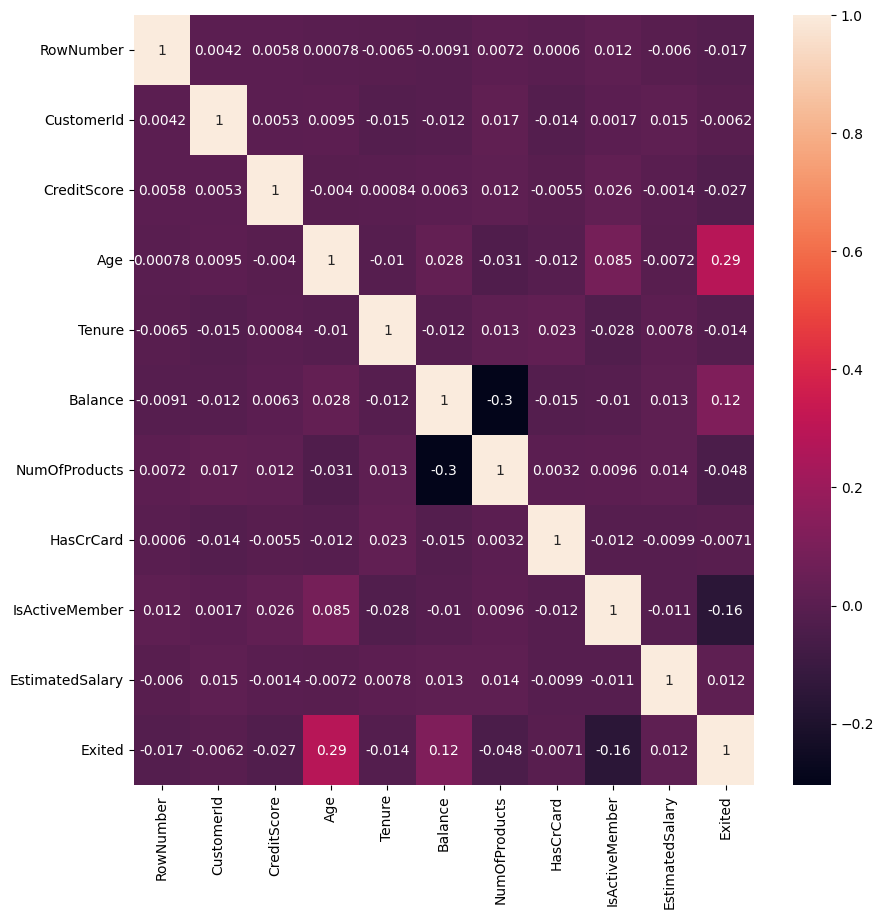

In [53]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Exited', ylabel='Count'>

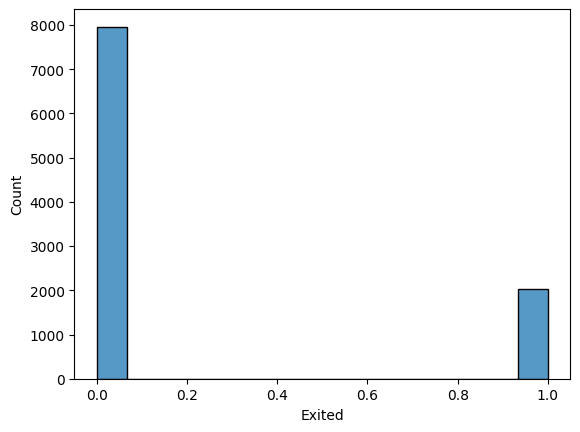

In [54]:
sns.histplot(df['Exited'])


<Axes: xlabel='Age', ylabel='Count'>

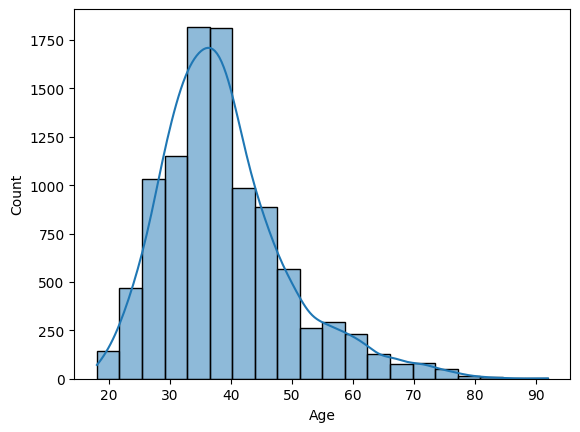

In [55]:
sns.histplot(df['Age'],bins=20,kde=True)

(array([3636.,  331., 1803., 2893., 1166.,  166.,    5.]),
 array([     0.        ,  35842.58428571,  71685.16857143, 107527.75285714,
        143370.33714286, 179212.92142857, 215055.50571429, 250898.09      ]),
 <BarContainer object of 7 artists>)

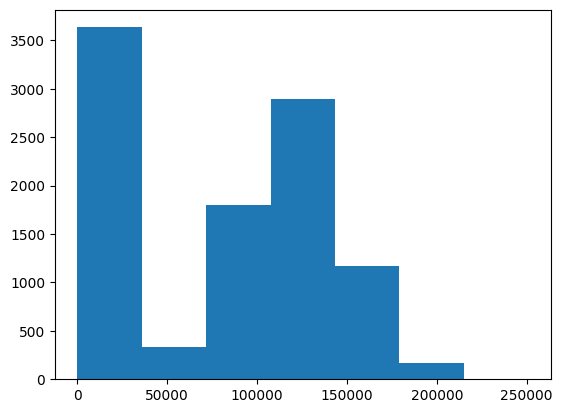

In [56]:
plt.hist(df['Balance'],bins=7)

<Axes: xlabel='EstimatedSalary', ylabel='Count'>

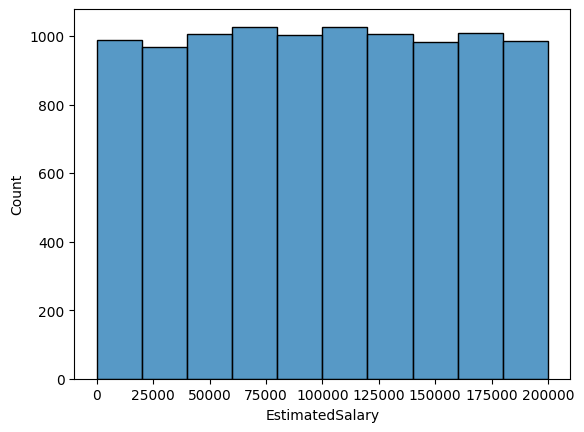

In [57]:
sns.histplot(df['EstimatedSalary'],bins=10)

<Axes: ylabel='Balance'>

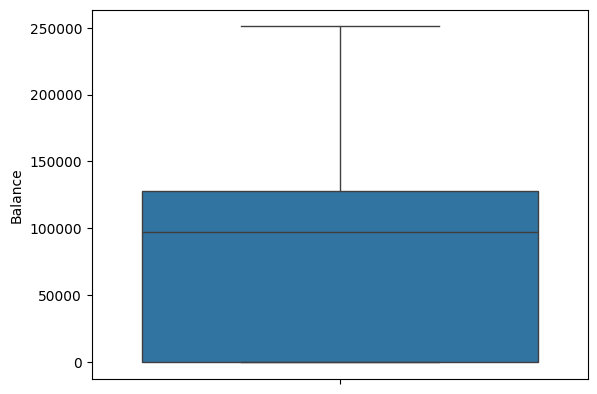

In [58]:
sns.boxplot(df['Balance'])

<Axes: xlabel='Age', ylabel='Balance'>

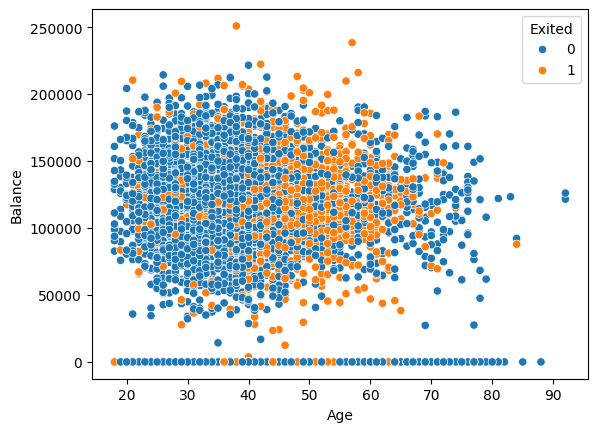

In [59]:
sns.scatterplot(x='Age',y='Balance',data=df,hue='Exited')

<Axes: xlabel='Geography', ylabel='count'>

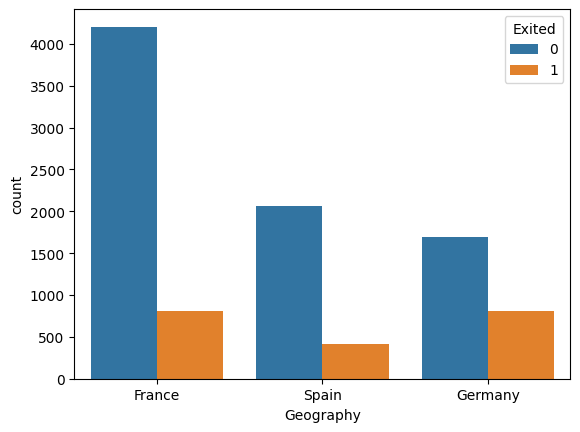

In [60]:
sns.countplot(x='Geography',hue='Exited',data=df)


In [61]:
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [64]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [65]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [66]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [67]:
# one-hot encoding
pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [68]:
X=df.drop(columns=['Exited'])
y=df['Exited']

In [69]:
from sklearn.model_selection import train_test_split
# train_test_split()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Perform one-hot encoding on X_train and X_test
X_train = pd.get_dummies(X_train, columns=['Geography', 'Gender'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Geography', 'Gender'], drop_first=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
# building ann

In [72]:
from tensorflow.keras import Sequential
from tensorflow.keras.activations import relu,sigmoid
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input

In [73]:
# model=Sequential()
# # input layer
# model.add(Dense(units=11,activation='relu'))
# model.add(Dropout(0.2))

In [74]:
# # 1st hidden layer
# model.add(Dense(units=7,activation='relu'))
# model.add(Dropout(0.2))

In [75]:
# # 2nd hidden layer
# model.add(Dense(units=6,activation='relu'))
# model.add(Dropout(0.2))

In [76]:
# # output layer
# model.add(Dense(units=1,activation='sigmoid'))

In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential([
    Input(shape=(11,)),
    Dense(11, activation='relu'),
    Dropout(0.2),

    Dense(7, activation='relu'),
    Dropout(0.2),

    Dense(6, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

In [78]:
early =tf.keras.callbacks.EarlyStopping(
monitor='val_loss',
    min_delta=0,
    patience=0,
    verbose=0,
    mode='auto',
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0
)

In [79]:
#  from keras.model loaded sequntial
# created model as sequntial
# from keras.layer using dense input layer
# 1st hidden layer
# 2nd hidden layer
# output layer
# we compile model by setting optimizer and loss function and accuracy metics
# we train for trinning data and test for testing data

# 111 dec 2025
# prediction
# evualtion
# early stopping

# dropout => to dead a neuron for overfitting for hidden layer
# earlystopping =>stops trinning the model once if the loss in not chaning ->for apply for traiing time

# 12/dec/2025
# plot => compare training loss
# plot => compare validation loss

In [80]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [48]:
model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.3, callbacks=[early])

Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7621 - loss: 0.5859 - val_accuracy: 0.7887 - val_loss: 0.5240
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7904 - loss: 0.5252 - val_accuracy: 0.7887 - val_loss: 0.4978
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7954 - loss: 0.5076 - val_accuracy: 0.7887 - val_loss: 0.4830
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7955 - loss: 0.4890 - val_accuracy: 0.7887 - val_loss: 0.4712
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7968 - loss: 0.4810 - val_accuracy: 0.7887 - val_loss: 0.4610
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.4702 - val_accuracy: 0.7887 - val_loss: 0.4549
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7968 - loss: 0.4627 - val_accuracy: 0.7887 - val_loss: 0.4514
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7973 - loss: 0.4608 - val_accu

In [81]:
y_pred = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [82]:
y_pred

array([[0.4935724 ],
       [0.51690453],
       [0.507804  ],
       ...,
       [0.5683104 ],
       [0.51027614],
       [0.46722972]], dtype=float32)

In [83]:
y_pred =(y_pred>0.5).astype(int)

In [84]:
y_pred

array([[0],
       [1],
       [1],
       ...,
       [1],
       [1],
       [0]])

In [85]:
# evualtion
from sklearn.metrics import accuracy_score,classification_report

In [86]:
y_pred_train = (model.predict(X_train_scaled) > 0.5).astype(int)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [87]:
y_pred_train

array([[1],
       [0],
       [1],
       ...,
       [0],
       [0],
       [0]])

In [88]:
accuracy_score(y_test,y_pred)

0.5385

In [89]:
accuracy_score(y_train,y_pred_train)

0.532125

In [90]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.57      0.67      1607
           1       0.18      0.39      0.25       393

    accuracy                           0.54      2000
   macro avg       0.49      0.48      0.46      2000
weighted avg       0.67      0.54      0.58      2000



In [93]:
model.save("model.h5")

In [94]:
import pickle

# save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# save column order
with open('columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns, f)
